# Working with complicated dataset

Your name: \


### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [93]:
import pandas as pd

url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

fields = [
    'query acc.ver', 'subject acc.ver', '% identity', 'alignment length',
    'mismatches', 'gap opens', 'q. start', 'q. end', 's. start',
    's. end', 'evalue', 'bit score', '% positives', 'bonds', 'publications', 'nan'
]

df = pd.read_csv(url, names=fields, header=None, skiprows=7)
df = df.drop(columns=['nan'])
df.drop(columns=['query acc.ver'], inplace=True)
df.set_index('subject acc.ver', inplace=True)
df.head()


,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3


### Question 2
What is the average number of publications?

In [94]:
df['publications'] = pd.to_numeric(df['publications'], errors='coerce')
df['publications'].mean()

np.float64(26.989690721649485)

### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [95]:
df['bonds'] = pd.to_numeric(df['bonds'].str.replace(',', ''))
df[df['bonds'] > 15000].index.tolist()

['AGK29621.1',
 'AHG32084.1',
 '6G2J_H',
 'YP_002791042.1',
 'AGK29634.1',
 '0806162F',
 'YP_009112408.1',
 'YP_001876469.1',
 'YP_009092269.1',
 'AHG32149.1',
 'YP_009092074.1',
 'YP_009450474.1',
 'YP_004123270.1',
 'YP_009092073.1',
 'AHZ60901.1',
 'YP_004123350.1',
 'YP_009453754.1',
 'ADD46492.1',
 'YP_007025968.1',
 'YP_009453806.1',
 'YP_007024956.1',
 'ASM92364.1',
 'YP_006073044.1',
 'ASM92494.1',
 'ADG95699.1',
 'YP_004891275.1',
 'YP_009166014.1',
 'YP_009538416.1',
 'YP_009414182.1',
 'YP_009178854.1',
 'YP_009414415.1',
 'YP_009353908.1',
 'YP_009093743.1',
 'ABX45285.1',
 'YP_009414156.1',
 'YP_009414363.1']

### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

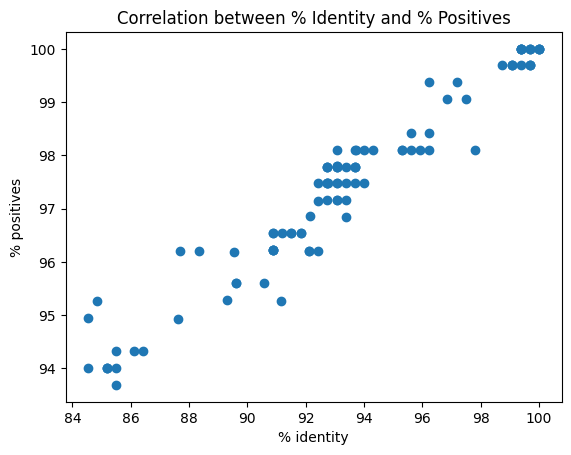

In [96]:
import matplotlib.pyplot as plt

plt.scatter(df['% identity'], df['% positives'])
plt.xlabel('% identity')
plt.ylabel('% positives')
plt.title('Correlation between % Identity and % Positives')
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [97]:
df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0


In [98]:
protein_source = pd.read_csv("https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv")

# Clean up df from previous failed attempts
cols_to_clear = ['level_0', 'index', 'Protein source', 'Source', 'Protein']
df = df.drop(columns=[c for c in cols_to_clear if c in df.columns])

df_reset = df.reset_index()
df_reset['subject acc.ver'] = df_reset['subject acc.ver'].astype(str)
protein_source['Protein'] = protein_source['Protein'].astype(str)

df_merged = df_reset.merge(protein_source, left_on='subject acc.ver', right_on='Protein', how='left')

cols_to_drop = [c for c in ['Protein', 'Unnamed: 0'] if c in df_merged.columns]
df_merged = df_merged.drop(columns=cols_to_drop)

if 'Source' in df_merged.columns:
    df_merged = df_merged.rename(columns={'Source': 'Protein source'})

df = df_merged.set_index('subject acc.ver')
df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
subject acc.ver,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0,NaN
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0,NaN
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0,NaN
